# Fundamentals of Quantum Algorithms: The Deutsch–Jozsa Algorithm

The **Deutsch–Jozsa algorithm** generalizes Deutsch's algorithm from functions of one bit to functions of $n$ bits. It solves the following problem in the **query model**:

> **Deutsch–Jozsa problem:** Given black-box (oracle) access to a function $f : \{0,1\}^n \to \{0,1\}$ that is *promised* to be either
> - **constant**: $f(x)$ is the same for all $2^n$ inputs, or
> - **balanced**: $f(x) = 0$ for exactly half of the inputs and $f(x) = 1$ for the other half,
>
> determine which one it is.

This is a **promise problem**: functions that are neither constant nor balanced are simply not allowed as inputs, and the algorithm's answer for them is meaningless. For $n = 1$ every function is either constant or balanced, so the problem reduces exactly to Deutsch's problem.

How many queries are needed?

| Approach | Queries | Guarantee |
|---|---|---|
| **Classical** (deterministic) | $2^{n-1} + 1$ in the worst case | Always correct |
| **Classical** (randomized) | $k$ | Wrong with probability at most $2^{1-k}$ |
| **Deutsch–Jozsa** | $1$ | Always correct |

A deterministic classical algorithm can see $2^{n-1}$ identical values from a balanced function before it finally sees a different one, so it needs one query more than half of all inputs to be certain. The quantum algorithm needs **a single query** for any $n$.

At the end of the notebook the same circuit is reused to solve the **Bernstein–Vazirani problem**, where the single query reveals an entire hidden $n$-bit string.

Topics covered:
- Building a random query gate $U_f$ that satisfies the Deutsch–Jozsa promise
- Extending the Deutsch's algorithm circuit to $n$ input qubits
- Why measuring all zeros means *constant* and anything else means *balanced*
- Solving the Bernstein–Vazirani problem with the same circuit

## Imports

- `QuantumCircuit` is used to build the query gates and the full algorithm circuit.
- `AerSimulator` (from the `qiskit-aer` package) is a local simulator used to run the circuits.
- `numpy` is used to make random choices when generating a query gate: whether the function is constant or balanced, and which inputs a balanced function maps to $1$.

In [17]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import numpy as np

## Section 1 — Generating a Random Query Gate

As in Deutsch's algorithm, the function is given as a reversible gate acting on $n$ **input** qubits $x = x_{n-1} \cdots x_1 x_0$ and one **output** qubit $y$:

$$U_f\,|y\rangle|x\rangle = |y \oplus f(x)\rangle|x\rangle$$

Qubits $0$ to $n-1$ hold the input and qubit $n$ holds the output.

`dj_query(num_qubits)` builds $U_f$ for a **random** function that satisfies the promise, so we can test the algorithm without knowing the answer in advance. It works as follows:

1. **`QuantumCircuit(num_qubits + 1)`**: create $n$ input qubits plus one output qubit.
2. **`qc.x(num_qubits)`** (applied with 50% probability): a NOT gate on the output adds $1$ to $f$ for every input, i.e. it replaces $f$ with $\lnot f$. Negation keeps a constant function constant and a balanced function balanced, so this just adds variety.
3. **`return qc`** (with 50% probability): stop here. The circuit is either empty ($f(x) = 0$) or a single X ($f(x) = 1$), so the function is **constant**.
4. **`np.random.choice(range(2**num_qubits), 2**num_qubits // 2, replace=False)`**: otherwise, pick $2^{n-1}$ *distinct* integers from $0$ to $2^n - 1$. These are the "on states": each one marks an input whose output will be flipped. Because exactly half of the inputs are chosen, the function is **balanced**.
5. For each chosen state, the loop adds a block that flips the output qubit for **exactly one input string**:
   - `add_cx(qc, bit_string)` applies an X gate to each input qubit whose bit is `1`. Despite its name, it adds X gates, not CNOTs. The string is `reversed` because Qiskit orders bits with qubit $0$ on the *right*, so the last character belongs to qubit $0$.
   - **`qc.mcx(list(range(num_qubits)), num_qubits)`** is a **multi-controlled X** (a Toffoli gate generalized to $n$ controls): it flips the output qubit only when *every* input qubit is $|1\rangle$.
   - Calling `add_cx` a second time applies the same X gates again, which undoes them and restores the input qubits.

   Together, the X gates and the `mcx` flip the output only for the one input that the X gates turn into $11\cdots1$. Here that is the **bitwise complement** of the chosen state, not the state itself. (`f"{state:0b}"` drops leading zeros, but qubits without an X gate must already be $1$, which matches the complement.) The complements of $2^{n-1}$ distinct states are still $2^{n-1}$ distinct inputs, so the function is still balanced.

Overall, each call returns a constant function with probability $1/2$ and a balanced function with probability $1/2$. The `barrier()` calls only separate the blocks in the drawing.

In [18]:
def dj_query(num_qubits):
    # Create a circuit implementing for a query gate for a random function
    # satisfying the promise for the Deutsch-Jozsa problem.

    qc = QuantumCircuit(num_qubits + 1)

    if np.random.randint(0, 2):
        # Flip output qubit with 50% chance
        qc.x(num_qubits)
    if np.random.randint(0, 2):
        # return constant circuit with 50% chance
        return qc

    # Choose half the possible input strings
    on_states = np.random.choice(
        range(2**num_qubits),  # numbers to sample from
        2**num_qubits // 2,  # number of samples
        replace=False,  # makes sure states are only sampled once
    )

    def add_cx(qc, bit_string):
        for qubit, bit in enumerate(reversed(bit_string)):
            if bit == "1":
                qc.x(qubit)
        return qc

    for state in on_states:
        qc.barrier()  # Barriers are added to help visualize how the functions are created.
        qc = add_cx(qc, f"{state:0b}")
        qc.mcx(list(range(num_qubits)), num_qubits)
        qc = add_cx(qc, f"{state:0b}")

    qc.barrier()

    return qc

### Visualizing a Random Query Gate

We draw a query gate for $n = 3$ input qubits ($q_0, q_1, q_2$) and the output qubit $q_3$. Since the function is random, the drawing changes every time the cell runs:
- A **constant** function shows either no gates or a single X on $q_3$.
- A **balanced** function shows $2^{3-1} = 4$ blocks between barriers. Each block is a layer of X gates, a multi-controlled X targeting $q_3$, and the same X gates again.

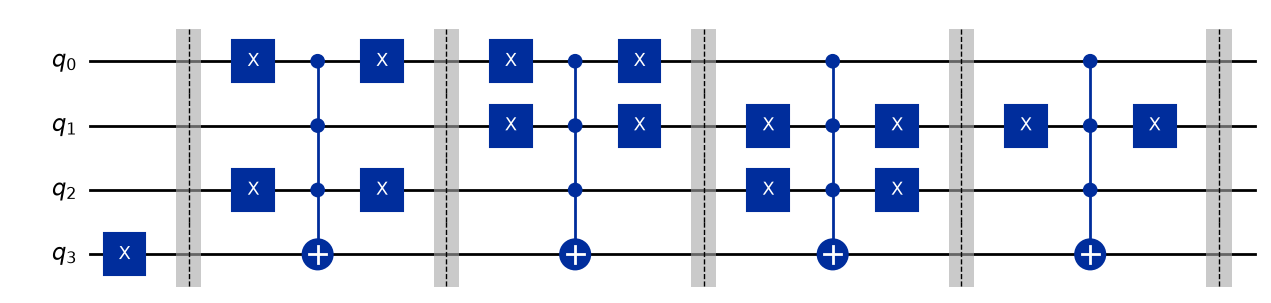

In [19]:
display(dj_query(3).draw(output="mpl"))

## Section 2 — Building the Deutsch–Jozsa Circuit

`compile_circuit(function)` is the same as in the Deutsch's algorithm notebook, but now $n$ can be larger than $1$ (and the barriers are left out, because the random query gate already has its own). With $n$ = `function.num_qubits - 1` input qubits:

1. **`QuantumCircuit(n + 1, n)`**: $n$ input qubits, one output qubit, and $n$ classical bits for the measurement results.
2. **`qc.x(n)`** and **`qc.h(range(n + 1))`**: put the output qubit in $|-\rangle$ and every input qubit in $|+\rangle$. The input register is now in an equal superposition of all $2^n$ input strings:
   $$|\pi_1\rangle = |-\rangle \otimes \frac{1}{\sqrt{2^n}} \sum_{x \in \{0,1\}^n} |x\rangle$$
3. **`qc.compose(function, inplace=True)`**: the single query to $U_f$. By **phase kickback**, each term picks up a phase $(-1)^{f(x)}$, and the output qubit is unchanged:
   $$|\pi_2\rangle = |-\rangle \otimes \frac{1}{\sqrt{2^n}} \sum_{x \in \{0,1\}^n} (-1)^{f(x)}|x\rangle$$
   All $2^n$ values of $f$ are now stored as phases, even though $U_f$ was applied only once.
4. **`qc.h(range(n))`**: apply Hadamard to every input qubit. This uses the identity
   $$H^{\otimes n}|x\rangle = \frac{1}{\sqrt{2^n}} \sum_{y \in \{0,1\}^n} (-1)^{x \cdot y}|y\rangle, \qquad x \cdot y = x_0 y_0 \oplus x_1 y_1 \oplus \cdots \oplus x_{n-1} y_{n-1}$$
   which gives
   $$|\pi_3\rangle = |-\rangle \otimes \sum_{y \in \{0,1\}^n} \left( \frac{1}{2^n} \sum_{x \in \{0,1\}^n} (-1)^{f(x) + x \cdot y} \right) |y\rangle$$
5. **`qc.measure(range(n), range(n))`**: measure the input qubits.

Only the amplitude of the all-zeros outcome $y = 0^n$ matters. Since $x \cdot 0^n = 0$ for every $x$, that amplitude is

$$\frac{1}{2^n} \sum_{x \in \{0,1\}^n} (-1)^{f(x)}$$

- If $f$ is **constant**, every term is the same ($+1$ or $-1$), so the amplitude is $\pm 1$. The outcome is $0^n$ **with certainty**.
- If $f$ is **balanced**, half the terms are $+1$ and half are $-1$, so they cancel and the amplitude is $0$. The outcome is **never** $0^n$.

So: **all zeros → constant**, **at least one 1 → balanced**.

In [20]:
def compile_circuit(function: QuantumCircuit):
    # Compiles a circuit for use in the Deutsch-Jozsa algorithm.

    n = function.num_qubits - 1
    qc = QuantumCircuit(n + 1, n)
    qc.x(n)
    qc.h(range(n + 1))
    qc.compose(function, inplace=True)
    qc.h(range(n))
    qc.measure(range(n), range(n))
    return qc

## Section 3 — Running the Algorithm

`dj_algorithm(function)` builds the circuit, runs it once, and reads the result:

1. **`shots=1`**: one run is enough, because in the noiseless case the outcome is deterministic: always $0^n$ for a constant function, never $0^n$ for a balanced one.
2. **`memory=True`** records each shot's result, which `result.get_memory()` returns as a list of bit strings, here one string such as `"000"` or `"101"`.
3. **`if "1" in measurements[0]`**: if any measured bit is `1`, the function is `"balanced"`. Otherwise all bits are `0` and it is `"constant"`.

For $n = 1$ this is exactly the `deutsch_algorithm` function from the previous notebook: the single measured bit is `"0"` for constant and `"1"` for balanced.

In [21]:
def dj_algorithm(function: QuantumCircuit):
    # Determine if a function is constant or balanced.

    qc = compile_circuit(function)

    result = AerSimulator().run(qc, shots=1, memory=True).result()
    measurements = result.get_memory()
    if "1" in measurements[0]:
        return "balanced"
    return "constant"

### Testing the Algorithm

We generate a random 3-bit query gate, draw it, and run the algorithm on it. Because the function is random, the result can change every time the cell runs. To check the answer, look at the drawing: a function with no multi-controlled X gates is constant, and one with four blocks is balanced. Run the cell several times to see both cases.

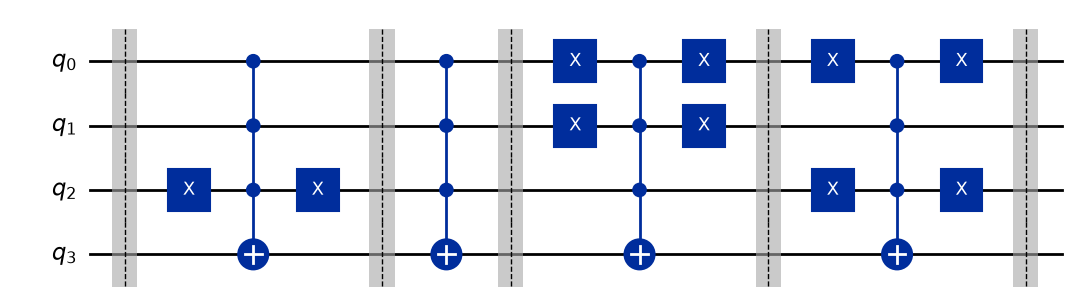

'balanced'

In [28]:
f = dj_query(3)
display(f.draw("mpl"))
display(dj_algorithm(f))

## Section 4 — The Bernstein–Vazirani Problem

The same circuit solves a different problem.

> **Bernstein–Vazirani problem:** Given black-box access to a function $f : \{0,1\}^n \to \{0,1\}$ that is promised to be
> $$f(x) = s \cdot x = s_0 x_0 \oplus s_1 x_1 \oplus \cdots \oplus s_{n-1} x_{n-1}$$
> for some unknown $n$-bit string $s$, find $s$.

A classical algorithm learns only one bit of information per query, so it needs $n$ queries. For example, querying $x = 0\cdots01$ reveals $s_0$, querying $x = 0\cdots10$ reveals $s_1$, and so on. The quantum algorithm needs **one query**.

`bv_query(s)` builds $U_f$ for a given secret string `s`:
- For every position where $s$ has a `1`, it adds a **CNOT** from that input qubit to the output qubit (`qc.cx(index, len(s))`). Each CNOT adds $x_i$ to the output, so together they add $\bigoplus_{i : s_i = 1} x_i = s \cdot x$.
- As in `dj_query`, the string is `reversed` so that the rightmost character of `s` belongs to qubit $0$.

For `s = "1011"`, the bits for qubits $0$, $1$ and $3$ are `1`, so the drawing shows CNOTs from $q_0$, $q_1$ and $q_3$ targeting the output qubit $q_4$.

> Note that $s \cdot x$ is constant when $s = 0^n$ and balanced otherwise, so these functions also satisfy the Deutsch–Jozsa promise.

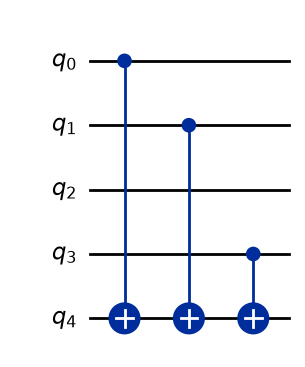

In [23]:
def bv_query(s):
    # Create a quantum circuit implementing a query gate for the
    # Bernstein-Vazirani problem.

    qc = QuantumCircuit(len(s) + 1)
    for index, bit in enumerate(reversed(s)):
        if bit == "1":
            qc.cx(index, len(s))
    return qc


display(bv_query("1011").draw(output="mpl"))

### Running the Bernstein–Vazirani Algorithm

`bv_algorithm(function)` uses the **same** `compile_circuit` as Deutsch–Jozsa, and returns the measured bit string itself instead of checking it for a `1`.

Why the output is exactly $s$: after the query, the input register holds

$$\frac{1}{\sqrt{2^n}} \sum_{x \in \{0,1\}^n} (-1)^{s \cdot x}|x\rangle = H^{\otimes n}|s\rangle$$

by the Hadamard identity from Section 2. Since $H^{\otimes n}$ is its own inverse, the final layer of Hadamards turns this state into $|s\rangle$, and measuring gives $s$ **with certainty**.

Qiskit writes the result with classical bit $0$ on the right, the same convention used to build the oracle, so the output `'1011'` matches the secret string exactly. Try other strings in `bv_query` to check that the algorithm always recovers them in a single query.

In [24]:
def bv_algorithm(function: QuantumCircuit):
    qc = compile_circuit(function)
    result = AerSimulator().run(qc, shots=1, memory=True).result()
    return result.get_memory()[0]


display(bv_algorithm(bv_query("1011")))

'1011'